**Lab2-DL: C2-cnn-training.ipynb** (BMED365) | Priority: 2 (recommended)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/C2-cnn-training.ipynb)

# 🚀 C2: CNN Training and Saving

Updated: 2025-12-22, A. Lundervold

**From Nature to Medicine: Train and Save the CNN Model**

---

## 🎯 Goals for This Section

In this notebook we will:
- **Load** model and data from part 1
- **Train** the CNN model with progress tracking
- **Visualize** training results
- **Save** the trained model and history
- **Prepare** for testing in part 3

## Prerequisites

This notebook builds on `C1-cnn-environment-architecture.ipynb`. Make sure you have:
- ✅ Completed part 1
- ✅ Saved model and data
- ✅ Understood the CNN architecture

## 🔧 Environment Setup

We start by setting up the environment and importing necessary libraries.

In [1]:
import sys
import subprocess
import os

# Check if we are running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab")
    
    # Install necessary packages
    !pip install seaborn --quiet
    
    # Check if the folder already exists
    if not os.path.exists('BMED365-2026/Lab2-DL'):
        print(" Downloading course material...")
        try:
            !git clone https://github.com/arvidl/BMED365-2026.git
            os.chdir('BMED365-2026/Lab2-DL')
        except:
            print("❌ Could not download course material")
            print("Download manually from: https://github.com/arvidl/BMED365-2026")
else:
    print("💻 Running locally or in Codespaces")
    
print("✅ Environment setup complete!")

💻 Running locally or in Codespaces
✅ Environment setup complete!


In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("📚 Libraries imported!")

📚 Libraries imported!


In [3]:
# Configure device (CPU, GPU, or MPS)
def setup_device():
    """Set up the best available device"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("🍎 Using MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("💻 Using CPU")
    
    return device

device = setup_device()
print(f"✅ Device set to: {device}")

🍎 Using MPS (Apple Silicon)
✅ Device set to: mps


## Load Model and Data

We load the model architecture and data that were saved in part 1.

In [4]:
# Load data info from part 1
try:
    with open('flower_data_info.pkl', 'rb') as f:
        data_info = pickle.load(f)
    
    # Unpack data
    X_train = data_info['X_train']
    y_train = data_info['y_train']
    X_val = data_info['X_val']
    y_val = data_info['y_val']
    X_test = data_info['X_test']
    y_test = data_info['y_test']
    class_names = data_info['class_names']
    class_mapping = data_info['class_mapping']
    num_classes = data_info['num_classes']
    
    print("✅ Data loaded from part 1!")
    print(f"📊 Training set: {len(X_train)} images")
    print(f" Validation set: {len(X_val)} images")
    print(f"📊 Test set: {len(X_test)} images")
    print(f" Classes: {class_names}")
    
except FileNotFoundError:
    print("❌ Could not find 'flower_data_info.pkl'")
    print("💡 Make sure you have completed part 1 first!")
    print("📁 Run '02a_cnn_bildeklassifikasjon.ipynb' first")
    raise

✅ Data loaded from part 1!
📊 Training set: 2569 images
 Validation set: 550 images
📊 Test set: 551 images
 Classes: ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']


In [5]:
# Define transformations (same as in part 1)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformations defined!")

✅ Transformations defined!


In [6]:
# Custom Dataset class (same as in part 1)
class FlowerDataset(Dataset):
    """Custom dataset for flower images"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transform
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Create datasets and DataLoaders (num_workers=0 for local execution)
train_dataset = FlowerDataset(X_train, y_train, train_transform)
val_dataset = FlowerDataset(X_val, y_val, val_transform)
test_dataset = FlowerDataset(X_test, y_test, val_transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✅ DataLoaders created with batch_size={batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

✅ DataLoaders created with batch_size=32
  Training batches: 81
  Validation batches: 18
  Test batches: 18


In [7]:
# Load model architecture
class SimpleCNN(nn.Module):
    """Simple CNN for flower classification"""
    
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Convolution block 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Convolution block 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Convolution block 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten for fully connected layers
        x = x.view(-1, 128 * 28 * 28)
        
        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model
model = SimpleCNN(num_classes=num_classes)
model = model.to(device)

print("✅ Model created and moved to device!")
print(f"🏗️ Model architecture: {model.__class__.__name__}")
print(f"📊 Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model created and moved to device!
🏗️ Model architecture: SimpleCNN
📊 Number of parameters: 51,476,549


## 🚀 Training Functions

Now we define the functions for training and validating the model.

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train the model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """Validate the model for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("✅ Training functions defined!")

✅ Training functions defined!


In [9]:
def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=0.001):
    """Train the model with progress tracking"""
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    
    # Store training history
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    patience_counter = 0
    
    print(" Starting training...")
    print("=" * 60)
    print(f"📊 Number of epochs: {num_epochs}")
    print(f"📊 Learning rate: {learning_rate}")
    print(f"📊 Batch size: {train_loader.batch_size}")
    print(f"📊 Device: {device}")
    print("=" * 60)
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Calculate time
        epoch_time = time.time() - epoch_start
        
        # Show progress
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"Epoch time: {epoch_time:.1f}s")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_flower_model.pth')
            print(f"💾 New best model saved! (Accuracy: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            print(f"⏳ No improvement for {patience_counter} epochs")
        
        if patience_counter >= 5:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
    
    total_time = time.time() - start_time
    
    print("\n✅ Training complete!")
    print(f"⏱️ Total time: {total_time/60:.1f} minutes")
    print(f" Best validation accuracy: {best_val_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses, 
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'total_time': total_time
    }

print("✅ Training function defined!")

✅ Training function defined!


## 🚀 Start Training

Now we start training the model. This may take a few minutes depending on your computing capacity (approximately 4.5 min on MacBook Pro M4 Max)

In [10]:
%%time
# Run training
print("🚀 Starting model training...")
print("⏳ This may take a few minutes depending on your device...")

history = train_model(model, train_loader, val_loader, num_epochs=25, learning_rate=0.001)

print("\n📊 Training results:")
print(f"  Final training accuracy: {history['train_accs'][-1]:.2f}%")
print(f"  Final validation accuracy: {history['val_accs'][-1]:.2f}%")
print(f"  Best validation accuracy: {history['best_val_acc']:.2f}%")
print(f"  Total training time: {history['total_time']/60:.1f} minutes")

🚀 Starting model training...
⏳ This may take a few minutes depending on your device...
 Starting training...
📊 Number of epochs: 25
📊 Learning rate: 0.001
📊 Batch size: 32
📊 Device: mps

Epoch 1/25
------------------------------
Training Loss: 1.7165, Training Accuracy: 33.09%
Validation Loss: 1.3065, Validation Accuracy: 41.45%
Learning Rate: 0.001000
Epoch time: 23.6s
💾 New best model saved! (Accuracy: 41.45%)

Epoch 2/25
------------------------------
Training Loss: 1.3535, Training Accuracy: 43.40%
Validation Loss: 1.2111, Validation Accuracy: 48.91%
Learning Rate: 0.001000
Epoch time: 9.9s
💾 New best model saved! (Accuracy: 48.91%)

Epoch 3/25
------------------------------
Training Loss: 1.2407, Training Accuracy: 47.18%
Validation Loss: 1.0861, Validation Accuracy: 56.18%
Learning Rate: 0.001000
Epoch time: 10.0s
💾 New best model saved! (Accuracy: 56.18%)

Epoch 4/25
------------------------------
Training Loss: 1.2047, Training Accuracy: 51.23%
Validation Loss: 1.0323, Validati

## 📈 Visualization of Training Results

Let's visualize how the model learned during training.

 Visualizing training results...


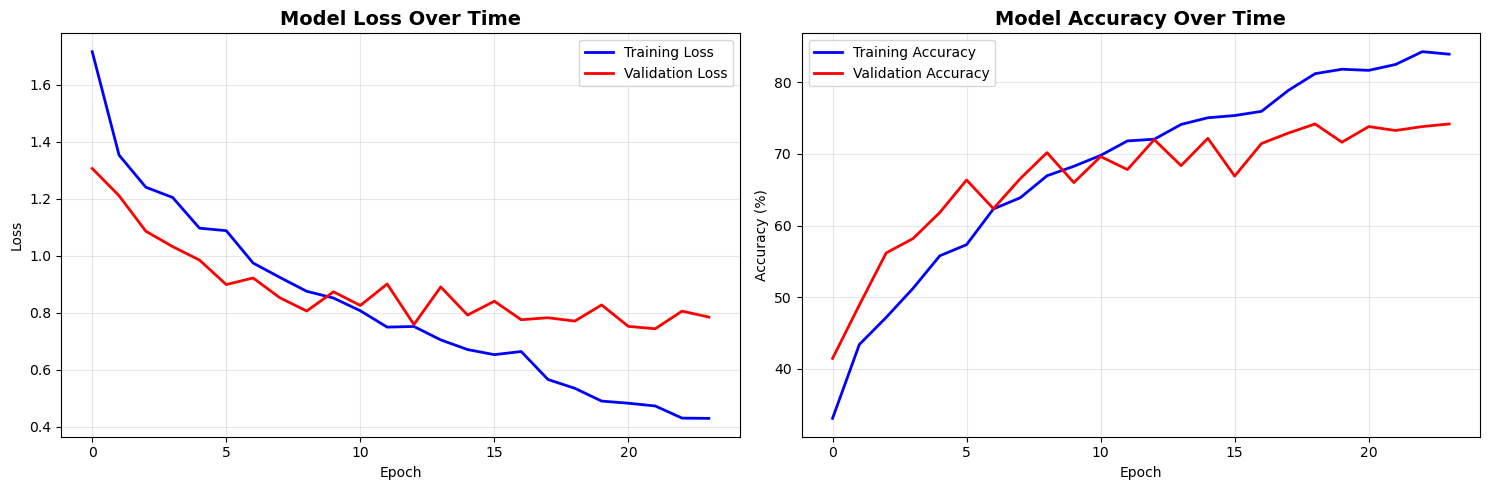

In [11]:
def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(history['train_losses'], label='Training Loss', color='blue', linewidth=2)
    axes[0].plot(history['val_losses'], label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_accs'], label='Training Accuracy', color='blue', linewidth=2)
    axes[1].plot(history['val_accs'], label='Validation Accuracy', color='red', linewidth=2)
    axes[1].set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot training history
print(" Visualizing training results...")
plot_training_history(history)

 Showing summary of training results...


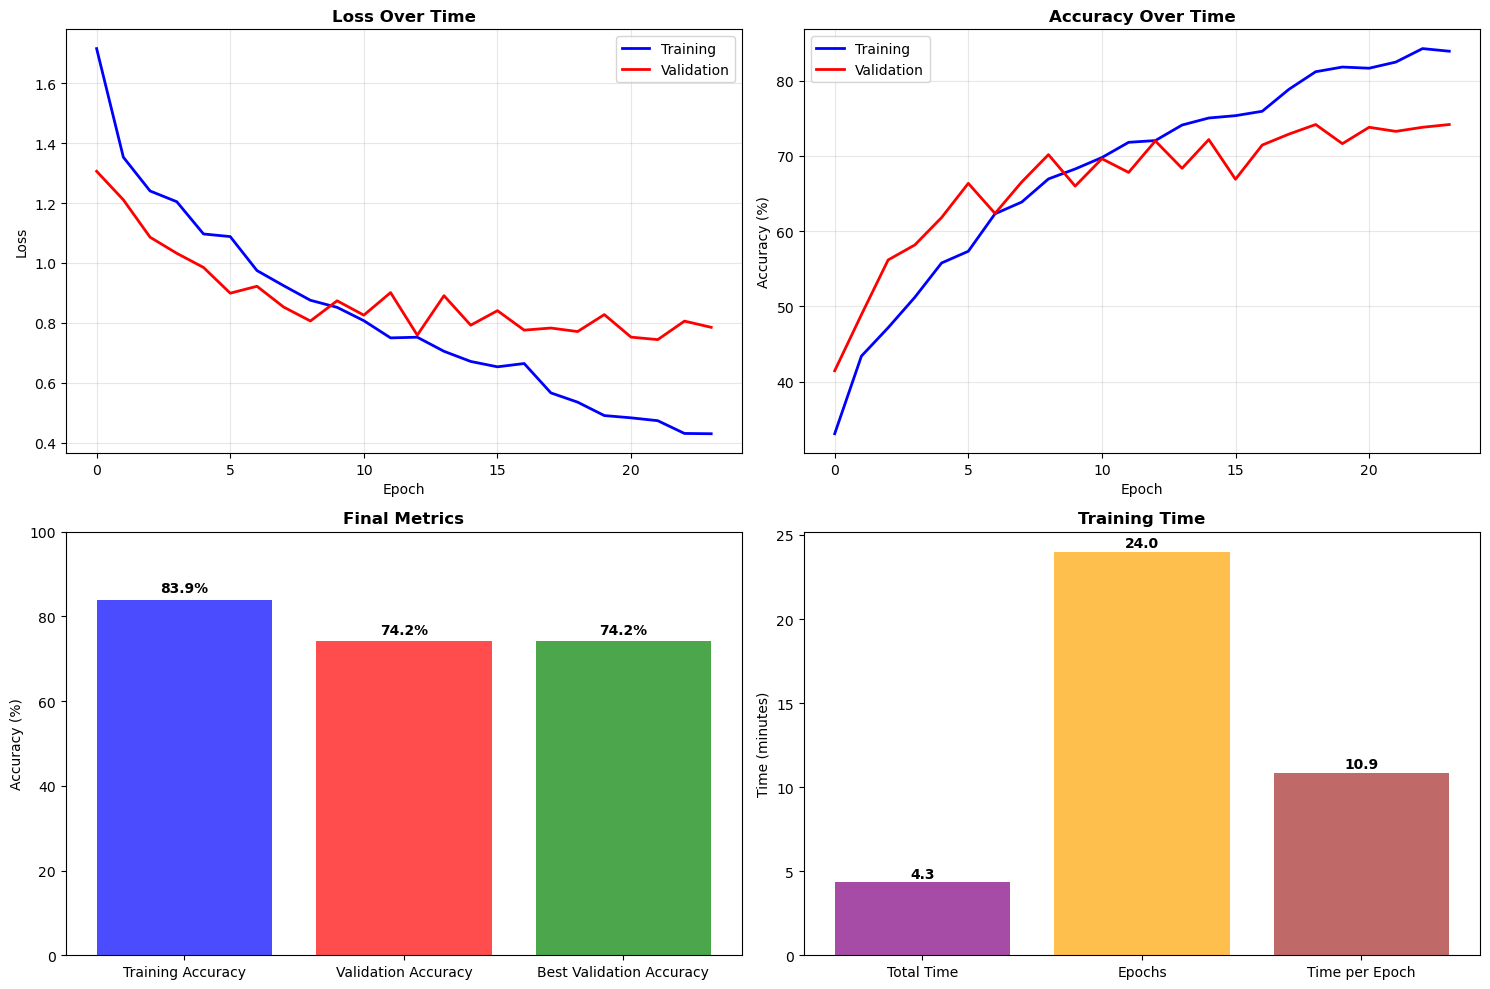

In [12]:
def plot_training_summary(history):
    """Plot summary of training results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Loss over time
    axes[0, 0].plot(history['train_losses'], label='Training', color='blue', linewidth=2)
    axes[0, 0].plot(history['val_losses'], label='Validation', color='red', linewidth=2)
    axes[0, 0].set_title('Loss Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Accuracy over time
    axes[0, 1].plot(history['train_accs'], label='Training', color='blue', linewidth=2)
    axes[0, 1].plot(history['val_accs'], label='Validation', color='red', linewidth=2)
    axes[0, 1].set_title('Accuracy Over Time', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Final metrics
    final_metrics = {
        'Training Accuracy': history['train_accs'][-1],
        'Validation Accuracy': history['val_accs'][-1],
        'Best Validation Accuracy': history['best_val_acc']
    }
    
    bars = axes[1, 0].bar(final_metrics.keys(), final_metrics.values(), 
                         color=['blue', 'red', 'green'], alpha=0.7)
    axes[1, 0].set_title('Final Metrics', fontweight='bold')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].set_ylim(0, 100)
    
    # Add values on bars
    for bar, value in zip(bars, final_metrics.values()):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Training time
    time_info = {
        'Total Time': history['total_time']/60,
        'Epochs': len(history['train_accs']),
        'Time per Epoch': history['total_time']/len(history['train_accs'])
    }
    
    bars = axes[1, 1].bar(time_info.keys(), time_info.values(), 
                         color=['purple', 'orange', 'brown'], alpha=0.7)
    axes[1, 1].set_title('Training Time', fontweight='bold')
    axes[1, 1].set_ylabel('Time (minutes)')
    
    # Add values on bars
    for bar, value in zip(bars, time_info.values()):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot summary
print(" Showing summary of training results...")
plot_training_summary(history)

## 🔍 Analysis of Training Results

Let's analyze the training results to understand how the model learned.

In [13]:
def analyze_training_results(history):
    """Analyze training results"""
    
    print(" Analysis of training results:")
    print("=" * 50)
    
    # Basic statistics
    final_train_acc = history['train_accs'][-1]
    final_val_acc = history['val_accs'][-1]
    best_val_acc = history['best_val_acc']
    
    print(f" Final training accuracy: {final_train_acc:.2f}%")
    print(f"📊 Final validation accuracy: {final_val_acc:.2f}%")
    print(f" Best validation accuracy: {best_val_acc:.2f}%")
    
    # Overfitting analysis
    overfitting_gap = final_train_acc - final_val_acc
    print(f"\n🔍 Overfitting analysis:")
    print(f"  Gap between training and validation accuracy: {overfitting_gap:.2f}%")
    
    if overfitting_gap > 10:
        print("  ⚠️ The model shows signs of overfitting (gap > 10%)")
    elif overfitting_gap > 5:
        print("  ⚠️ The model shows moderate signs of overfitting (gap > 5%)")
    else:
        print("  ✅ The model generalizes well (small gap)")
    
    # Convergence analysis
    print(f"\n Convergence analysis:")
    print(f"  Number of epochs: {len(history['train_accs'])}")
    print(f"  Total training time: {history['total_time']/60:.1f} minutes")
    print(f"  Average time per epoch: {history['total_time']/len(history['train_accs']):.1f} seconds")
    
    # Performance evaluation
    print(f"\n🔍 Performance evaluation:")
    if best_val_acc >= 90:
        print("  Excellent performance! (≥90%)")
    elif best_val_acc >= 80:
        print("  Good performance! (≥80%)")
    elif best_val_acc >= 70:
        print("  👍 Acceptable performance (≥70%)")
    else:
        print("  ⚠️ The model needs improvement (<70%)")
    
    # Recommendations
    print(f"\n💡 Recommendations:")
    if overfitting_gap > 10:
        print("  - Increase the dropout rate")
        print("  - Add more data augmentation")
        print("  - Reduce model complexity")
    
    if best_val_acc < 80:
        print("  - Train for more epochs")
        print("  - Try different learning rates")
        print("  - Consider changing the model architecture")
    
    if best_val_acc >= 80:
        print("  - The model is ready for evaluation!")
        print("  - Proceed to part 3 for testing")

# Analyze results
analyze_training_results(history)

 Analysis of training results:
 Final training accuracy: 83.92%
📊 Final validation accuracy: 74.18%
 Best validation accuracy: 74.18%

🔍 Overfitting analysis:
  Gap between training and validation accuracy: 9.74%
  ⚠️ The model shows moderate signs of overfitting (gap > 5%)

 Convergence analysis:
  Number of epochs: 24
  Total training time: 4.3 minutes
  Average time per epoch: 10.9 seconds

🔍 Performance evaluation:
  👍 Acceptable performance (≥70%)

💡 Recommendations:
  - Train for more epochs
  - Try different learning rates
  - Consider changing the model architecture


## 💾 Saving the Trained Model

We save the trained model and training history for use in part 3.

In [14]:
# Load best model
model.load_state_dict(torch.load('best_flower_model.pth'))
print("✅ Best model loaded!")

# Save complete model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'SimpleCNN',
    'num_classes': num_classes,
    'class_names': class_names,
    'class_mapping': class_mapping,
    'training_history': history
}, 'trained_flower_model.pth')

# Save training history separately
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("✅ Model and history saved!")
print(" Files created:")
print("  - best_flower_model.pth (best model)")
print("  - trained_flower_model.pth (complete model)")
print("  - training_history.pkl (training history)")

✅ Best model loaded!
✅ Model and history saved!
 Files created:
  - best_flower_model.pth (best model)
  - trained_flower_model.pth (complete model)
  - training_history.pkl (training history)


## Summary and Next Steps

### What we have accomplished:
- ✅ Loaded model and data from part 1
- ✅ Trained the CNN model with progress tracking
- ✅ Visualized training results
- ✅ Analyzed model performance
- ✅ Saved trained model and history

### Next steps (part 3):
- 🧪 Testing the model on the test set
- 🔍 Confusion matrix and metrics
- 🔍 Explainable AI (CAM, Grad-CAM)
- 🔍 Detailed evaluation

### Reflection questions:
1. **Why** do we use early stopping in training?
2. **What** do the training curves tell us about the model's learning?
3. **How** can we identify overfitting?
4. **Why** is it important to save both model and history?

---

**Proceed to part 3: `C3-cnn-testing-gradcam.ipynb`**